### Commenti vari:
Alcuni commenti su un piccolo confronto tra semafori stupidi e intelligenti (vedi fondo notebook):
- possiamo togliere i primi 10-15 cicli in modo da evitare bruschi innalzamenti di variabili che ci fanno apprezzare meno i cambiamenti.
- Ci sono più righe per stupidi e godly che per intelligenti (simulazioni non fermate nello stesso momento, possibile modificare i dataframe per farli combaciare);
- Velocità media cresce con gli intelligenti;
- Accelerazione cumulata diminuisce (buono);
- Delta medio prima diminuisce e poi aumenta di nuovo, da capire;
- Flussi aumentano, buoni

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns

In [3]:
folder = r"C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/"
intelligent_list = [f"{folder}intelligent{i}.csv" for i in range(234, 239)]
print(intelligent_list)    


['C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/intelligent234.csv', 'C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/intelligent235.csv', 'C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/intelligent236.csv', 'C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/intelligent237.csv', 'C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/intelligent238.csv']


In [4]:
stupid_list = [f"{folder}stupid_{i}.csv" for i in range(234, 239)]
print(stupid_list)

['C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/stupid_234.csv', 'C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/stupid_235.csv', 'C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/stupid_236.csv', 'C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/stupid_237.csv', 'C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/stupid_238.csv']


In [5]:
godly_list = [f"{folder}godly_{i}.csv" for i in range(234, 239)]
print(godly_list)

['C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/godly_234.csv', 'C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/godly_235.csv', 'C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/godly_236.csv', 'C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/godly_237.csv', 'C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/godly_238.csv']


In [6]:
df_prova = pd.read_csv(stupid_list[0])
df_prova.head()

,cycle,length(car),delta_medio,flusso_medio,vel_media,auto_ferme,cum_acc,n_trips
0,0,3500,0.000000,0.000000,0.000000,99.971437,0.000000,0
1,60,3500,37.143307,3.340909,14.300150,18.708940,601.689803,60
2,120,3499,37.479450,8.550000,14.644224,36.942857,737.536093,89
3,180,3499,38.651937,14.740909,18.302788,40.228571,669.307762,141
4,240,3500,39.652992,22.181818,11.762829,63.010568,535.529846,224


### Dizionario

ora creo un dizionario con i dataframe, in modo da associare chiave (nome file) con valore (dataframe), in modo da poter accedere direttamente alle varie colonne per poi fare i grafici

In [7]:
# Crea un dizionario di DataFrame
dfs_stupid = {}

for path in stupid_list:
    key = path.replace("C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/", "")
    key = key.replace(".csv", "")# es: "intelligent234"
    dfs_stupid[key] = pd.read_csv(path)

# Ora puoi accedere ai DataFrame così:
# dfs["intelligent234"], dfs["intelligent235"], ecc.

In [8]:
dfs_stupid.items()

dict_items([('stupid_234',      cycle  length(car)  delta_medio  flusso_medio  vel_media  auto_ferme  \
0        0         3500     0.000000      0.000000   0.000000   99.971437   
1       60         3500    37.143307      3.340909  14.300150   18.708940   
2      120         3499    37.479450      8.550000  14.644224   36.942857   
3      180         3499    38.651937     14.740909  18.302788   40.228571   
4      240         3500    39.652992     22.181818  11.762829   63.010568   
..     ...          ...          ...           ...        ...         ...   
134   8040         3500    76.634448    100.786364  13.890769   43.073408   
135   8100         3499    74.506720    107.727273  14.363429   52.685714   
136   8160         3499    75.684376    114.690909  11.944019   63.914286   
137   8220         3500    74.127138    122.190909  11.959532   33.704656   
138   8280         3499    74.590712    129.281818  13.140329   42.257143   

        cum_acc  n_trips  
0      0.000000      

In [9]:
dfs_stupid["stupid_234"]

,cycle,length(car),delta_medio,flusso_medio,vel_media,auto_ferme,cum_acc,n_trips
0,0,3500,0.000000,0.000000,0.000000,99.971437,0.000000,0
1,60,3500,37.143307,3.340909,14.300150,18.708940,601.689803,60
2,120,3499,37.479450,8.550000,14.644224,36.942857,737.536093,89
3,180,3499,38.651937,14.740909,18.302788,40.228571,669.307762,141
4,240,3500,39.652992,22.181818,11.762829,63.010568,535.529846,224
...,...,...,...,...,...,...,...,...
134,8040,3500,76.634448,100.786364,13.890769,43.073408,130.720737,28153
135,8100,3499,74.506720,107.727273,14.363429,52.685714,130.655419,28366
136,8160,3499,75.684376,114.690909,11.944019,63.914286,130.527607,28590
137,8220,3500,74.127138,122.190909,11.959532,33.704656,130.506465,28811


In [10]:
# Crea un dizionario di DataFrame
dfs_intelligent = {}

for path in intelligent_list:
    key = path.replace("C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/", "")
    key = key.replace(".csv", "")# es: "intelligent234"
    dfs_intelligent[key] = pd.read_csv(path)

# Ora puoi accedere ai DataFrame così:
# dfs["intelligent234"], dfs["intelligent235"], ecc.

In [11]:
dfs_intelligent["intelligent234"]

,cycle,length(car),delta_medio,flusso_medio,vel_media,auto_ferme,cum_acc,n_trips
0,0,4500,0.000000,0.000000,0.000000,99.977783,0.000000,0
1,0,3500,0.000000,0.000000,0.000000,99.971437,0.000000,0
2,60,3500,37.412086,3.950000,18.486283,39.360183,637.767871,62
3,120,3500,38.756953,11.136364,19.666190,29.562982,687.966050,108
4,180,3500,40.731869,20.604545,19.112966,30.334190,572.506495,191
...,...,...,...,...,...,...,...,...
118,7020,3500,84.219353,583.586364,17.491672,33.219080,114.904606,34803
119,7080,3500,83.726621,594.154545,18.980093,25.935447,114.909648,35099
120,7140,3500,85.650746,604.222727,18.155477,30.562696,114.940911,35377
121,7200,3500,87.733509,614.222727,18.137584,28.249072,114.834320,35704


In [12]:
# Crea un dizionario di DataFrame
dfs_godly = {}

for path in godly_list:
    key = path.replace("C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/", "")
    key = key.replace(".csv", "")
    dfs_godly[key] = pd.read_csv(path)

In [13]:
dfs_godly["godly_234"]

,cycle,length(car),delta_medio,flusso_medio,vel_media,auto_ferme,cum_acc,n_trips
0,0,3500,0.000000,0.000000,0.000000,99.971437,0.000000,0
1,60,3500,37.237419,3.931818,17.993456,28.363325,631.718366,64
2,120,3499,38.401820,11.490909,20.268061,22.371429,667.544061,113
3,180,3499,40.503813,20.931818,18.150288,27.257143,493.464376,221
4,240,3499,42.811087,31.627273,18.935101,28.200000,403.539850,355
...,...,...,...,...,...,...,...,...
127,7620,3499,73.516322,62.613636,16.823533,36.285714,114.356462,34882
128,7680,3500,74.138135,72.027273,16.149490,34.961440,114.240453,35175
129,7740,3499,75.921003,80.286364,16.367431,35.085714,114.212258,35448
130,7800,3499,77.178928,89.945455,17.225443,34.571429,114.156193,35735


## Grafici

Adesso facciamo una prova con la colonna vel_media, ad es per dfs stupid_234 e intelligent234

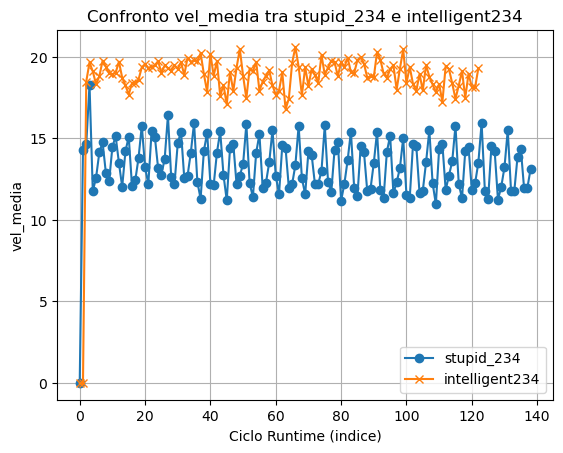

In [14]:
df_stupid = dfs_stupid["stupid_234"]
df_intelligent = dfs_intelligent["intelligent234"]

# Plot lineare o scatter
plt.plot(df_stupid['vel_media'].values, label='stupid_234', marker='o')
plt.plot(df_intelligent['vel_media'].values, label='intelligent234', marker='x')

plt.title('Confronto vel_media tra stupid_234 e intelligent234')
plt.ylabel('vel_media')
plt.xlabel('Ciclo Runtime (indice)')
plt.legend()
plt.grid(True)
plt.show()

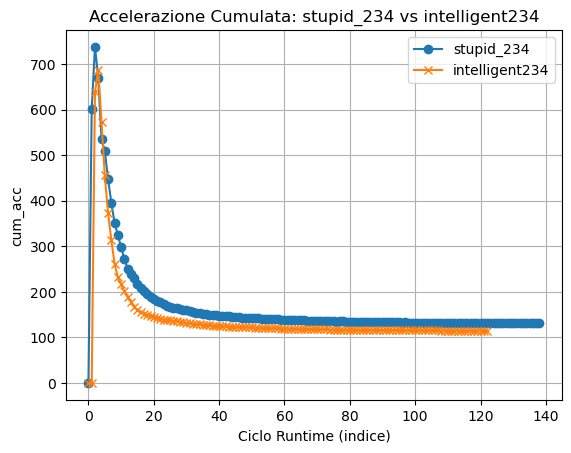

In [15]:
# Plot accelerazione cumulata
plt.plot(df_stupid['cum_acc'].values, label='stupid_234', marker='o')
plt.plot(df_intelligent['cum_acc'].values, label='intelligent234', marker='x')

plt.title('Accelerazione Cumulata: stupid_234 vs intelligent234')
plt.ylabel('cum_acc')
plt.xlabel('Ciclo Runtime (indice)')
plt.legend()
plt.grid(True)
plt.show()

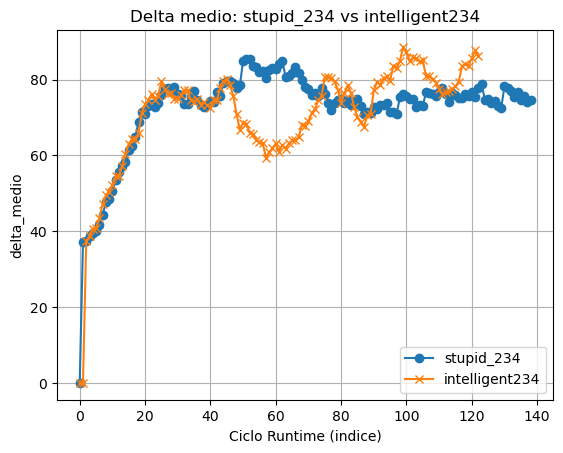

In [16]:
# confronto delta per rerouting
plt.plot(df_stupid['delta_medio'].values, label='stupid_234', marker='o')
plt.plot(df_intelligent['delta_medio'].values, label='intelligent234', marker='x')

plt.title('Delta medio: stupid_234 vs intelligent234')
plt.ylabel('delta_medio')
plt.xlabel('Ciclo Runtime (indice)')
plt.legend()
plt.grid(True)
plt.show()

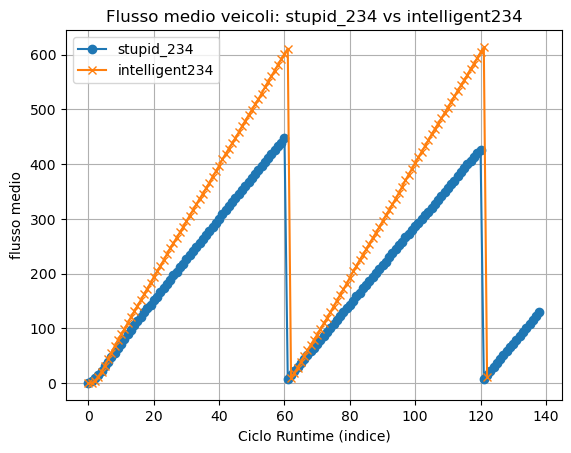

In [17]:
#flusso medio
plt.plot(df_stupid['flusso_medio'].values, label='stupid_234', marker='o')
plt.plot(df_intelligent['flusso_medio'].values, label='intelligent234', marker='x')

plt.title('Flusso medio veicoli: stupid_234 vs intelligent234')
plt.ylabel('flusso medio')
plt.xlabel('Ciclo Runtime (indice)')
plt.legend()
plt.grid(True)
plt.show()

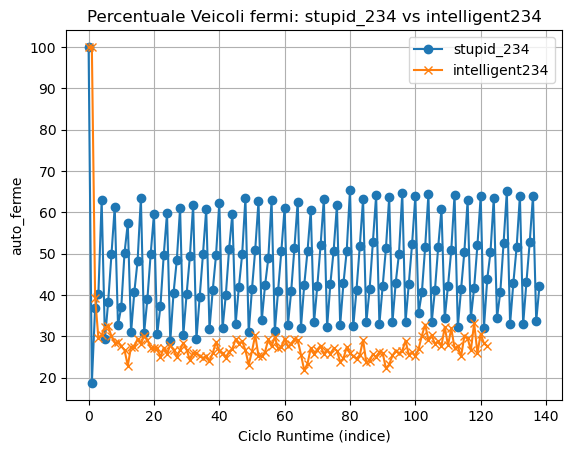

In [18]:
#auto ferme percentuale
plt.plot(df_stupid['auto_ferme'].values, label='stupid_234', marker='o')
plt.plot(df_intelligent['auto_ferme'].values, label='intelligent234', marker='x')

plt.title('Percentuale Veicoli fermi: stupid_234 vs intelligent234')
plt.ylabel('auto_ferme')
plt.xlabel('Ciclo Runtime (indice)')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
dfs_intelligent["intelligent235"]

,cycle,length(car),delta_medio,flusso_medio,vel_media,auto_ferme,cum_acc,n_trips
0,0,3500,0.000000,0.000000,0.000000,99.971437,0.000000,0
1,60,3500,41.333981,3.918182,18.859006,38.103399,471.872337,84
2,120,3500,42.004155,10.586364,19.826526,28.506141,495.435453,150
3,180,3500,42.838123,20.145455,19.114204,29.420166,421.920034,259
4,240,3500,45.448679,30.727273,19.702920,28.163382,376.628351,383
...,...,...,...,...,...,...,...,...
117,7020,3499,71.634957,590.827273,19.659746,22.800000,114.420997,35130
118,7080,3499,74.313554,600.781818,18.256818,30.200000,114.364774,35445
119,7140,3500,75.349809,611.118182,19.802993,26.935161,114.459728,35716
120,7200,3499,76.532508,621.690909,19.575701,24.200000,114.398054,36034


In [20]:
# Funzione per tagliare tutti i dataframe di un dizionario
def truncate_dfs(dfs_dict, max_rows=123):
    return {k: df.iloc[:max_rows] for k, df in dfs_dict.items()}

# Applichiamolo ai 3 dizionari
dfs_stupid = truncate_dfs(dfs_stupid)
dfs_intelligent = truncate_dfs(dfs_intelligent)
dfs_godly = truncate_dfs(dfs_godly)

In [21]:
dfs_stupid["stupid_234"]

,cycle,length(car),delta_medio,flusso_medio,vel_media,auto_ferme,cum_acc,n_trips
0,0,3500,0.000000,0.000000,0.000000,99.971437,0.000000,0
1,60,3500,37.143307,3.340909,14.300150,18.708940,601.689803,60
2,120,3499,37.479450,8.550000,14.644224,36.942857,737.536093,89
3,180,3499,38.651937,14.740909,18.302788,40.228571,669.307762,141
4,240,3500,39.652992,22.181818,11.762829,63.010568,535.529846,224
...,...,...,...,...,...,...,...,...
118,7080,3499,76.167387,413.340909,14.249656,41.771429,131.514743,24711
119,7140,3499,75.768663,419.904545,14.474206,52.000000,131.358363,24938
120,7200,3500,76.656654,426.313636,11.861091,63.838903,131.210608,25161
121,7260,3499,75.536406,7.268182,12.242209,32.057143,131.164050,25386


### Togliamo i primi 10-15 cicli

Per chiarezza nella visualizzazione dei grafici, vogliamo tagliare i primi 10-15 cicli, in modo da semplificare i plot

In [22]:
def trim_dfs(dfs_dict, start=15):
    return {k: df.iloc[start:] for k, df in dfs_dict.items()}

# Applichiamola
dfs_stupid = trim_dfs(dfs_stupid)
dfs_intelligent = trim_dfs(dfs_intelligent)
dfs_godly = trim_dfs(dfs_godly)

In [23]:
dfs_stupid["stupid_234"]

,cycle,length(car),delta_medio,flusso_medio,vel_media,auto_ferme,cum_acc,n_trips
15,900,3500,61.354100,113.086364,15.103490,48.271922,217.597313,1976
16,960,3499,62.619156,120.000000,12.084477,63.514286,208.345614,2189
17,1020,3500,64.824941,128.836364,12.419217,30.848329,200.833537,2420
18,1080,3499,68.773787,136.304545,13.803580,39.057143,194.477542,2643
19,1140,3500,71.446574,142.777273,15.786549,49.900029,188.604423,2874
...,...,...,...,...,...,...,...,...
118,7080,3499,76.167387,413.340909,14.249656,41.771429,131.514743,24711
119,7140,3499,75.768663,419.904545,14.474206,52.000000,131.358363,24938
120,7200,3500,76.656654,426.313636,11.861091,63.838903,131.210608,25161
121,7260,3499,75.536406,7.268182,12.242209,32.057143,131.164050,25386


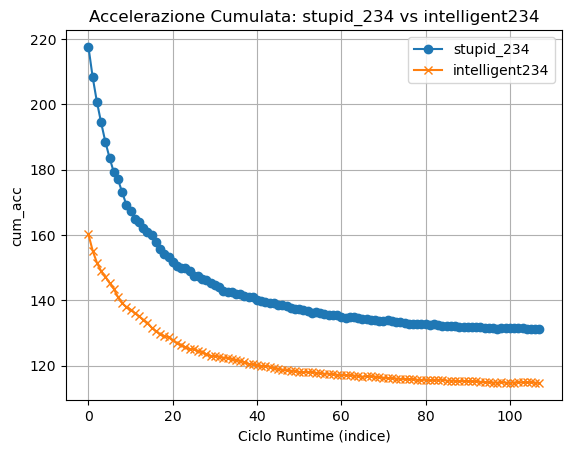

In [25]:
df_stupid = dfs_stupid["stupid_234"]
df_intelligent = dfs_intelligent["intelligent234"]
# Plot accelerazione cumulata
plt.plot(df_stupid['cum_acc'].values, label='stupid_234', marker='o')
plt.plot(df_intelligent['cum_acc'].values, label='intelligent234', marker='x')

plt.title('Accelerazione Cumulata: stupid_234 vs intelligent234')
plt.ylabel('cum_acc')
plt.xlabel('Ciclo Runtime (indice)')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
import os
plot_folder = r"C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/plots"
nome_acc = "accelerazione.png"
path_acc = os.path.join(plot_folder, nome_acc)

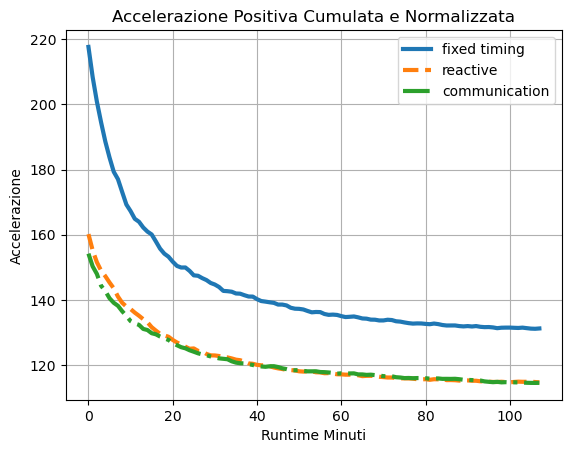

In [31]:
# Accelerazione con seed 234
df_stupid = dfs_stupid["stupid_234"]
df_intelligent = dfs_intelligent["intelligent234"]
df_godly = dfs_godly["godly_234"]
# Plot accelerazione cumulata
plt.plot(df_stupid['cum_acc'].values,linestyle='-',linewidth=3, label='fixed timing')
plt.plot(df_intelligent['cum_acc'].values, linestyle='--',linewidth=3, label='reactive')
plt.plot(df_godly['cum_acc'].values,linestyle='-.',linewidth=3, label='communication')

plt.title('Accelerazione Positiva Cumulata e Normalizzata')
plt.ylabel('Accelerazione')
plt.xlabel('Runtime Minuti')
plt.legend()
plt.grid(True)

#salva
plt.savefig(path_acc, dpi=300, bbox_inches='tight')
plt.show()

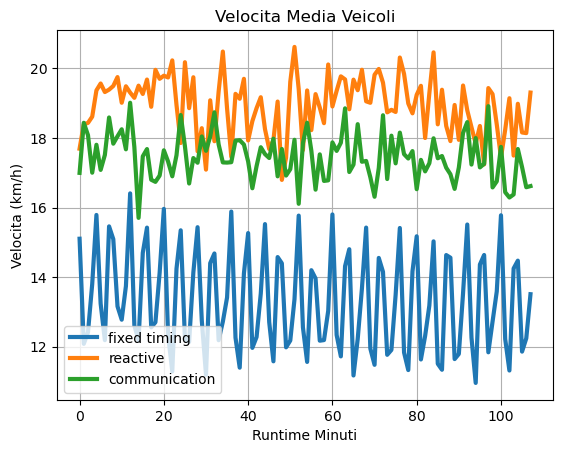

In [33]:
nome_vel = "velocity.png"
path_vel = os.path.join(plot_folder, nome_vel)

#plot velocità
plt.plot(df_stupid['vel_media'].values,linestyle='-',linewidth=3, label='fixed timing')
plt.plot(df_intelligent['vel_media'].values, linestyle='-',linewidth=3, label='reactive')
plt.plot(df_godly['vel_media'].values,linestyle='-',linewidth=3, label='communication')

plt.title('Velocita Media Veicoli')
plt.ylabel('Velocita (km/h)')
plt.xlabel('Runtime Minuti')
plt.legend()
plt.grid(True)

#salva
plt.savefig(path_vel, dpi=300, bbox_inches='tight')
plt.show()

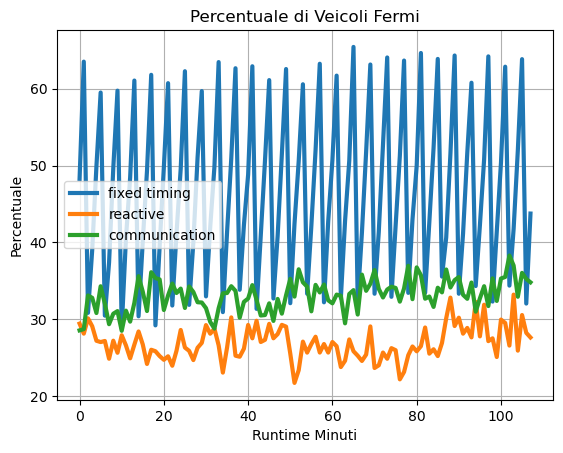

In [40]:
nome_fermi = "veicoli_fermi.png"
path_fermi = os.path.join(plot_folder, nome_fermi)

#plot veicoli fermi
plt.plot(df_stupid['auto_ferme'].values,linestyle='-',linewidth=3, label='fixed timing')
plt.plot(df_intelligent['auto_ferme'].values, linestyle='-',linewidth=3, label='reactive')
plt.plot(df_godly['auto_ferme'].values,linestyle='-',linewidth=3, label='communication')

plt.title('Percentuale di Veicoli Fermi')
plt.ylabel('Percentuale')
plt.xlabel('Runtime Minuti')
plt.legend()
plt.grid(True)

#salva
plt.savefig(path_fermi, dpi=300, bbox_inches='tight')
plt.show()

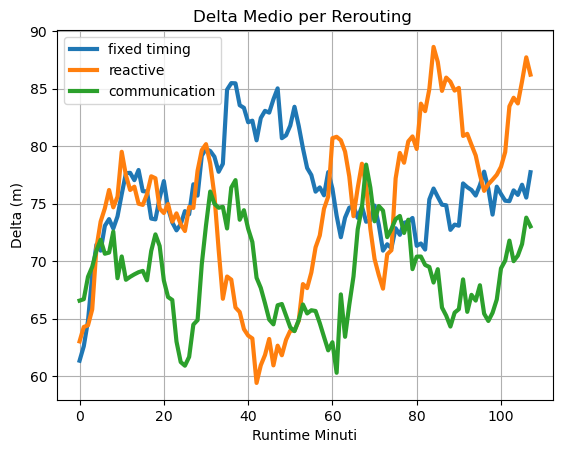

In [42]:
nome_delta = "delta_medio.png"
path_delta = os.path.join(plot_folder, nome_delta)

#plot veicoli fermi
plt.plot(df_stupid['delta_medio'].values,linestyle='-',linewidth=3, label='fixed timing')
plt.plot(df_intelligent['delta_medio'].values, linestyle='-',linewidth=3, label='reactive')
plt.plot(df_godly['delta_medio'].values,linestyle='-',linewidth=3, label='communication')

plt.title('Delta Medio per Rerouting ')
plt.ylabel('Delta (m)')
plt.xlabel('Runtime Minuti')
plt.legend()
plt.grid(True)

#salva
plt.savefig(path_delta, dpi=300, bbox_inches='tight')
plt.show()

In [62]:
#folder = r"C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/"
stress_list = [f"{folder}stress_batch_{i}.csv" for i in ['stupid_1','intelligent_1', 'godly_1']]
print(stress_list)   

['C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/stress_batch_stupid_1.csv', 'C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/stress_batch_intelligent_1.csv', 'C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/stress_batch_godly_1.csv']


In [63]:
dfs_stress = {}

for path in stress_list:
    key = path.replace("C:/Users/alezo/Desktop/Programmazione/GitWork/AB-lights/results/", "")
    key = key.replace(".csv", "")
    dfs_stress[key] = pd.read_csv(path)

# Ora puoi accedere ai DataFrame così:
# dfs["intelligent234"], dfs["intelligent235"], ecc.

In [64]:
dfs_stress["stress_batch_godly_1"].tail()

,cycle,length(car),delta_medio,flusso_medio,vel_media,auto_ferme,cum_acc,n_trips
191,11460,11894,85.917633,160.513636,8.140499,62.379151,128.287759,68346
192,11520,12000,86.337545,175.095455,7.102569,66.452796,128.415089,68704
193,11580,12000,87.135226,187.863636,7.396494,67.061078,128.417007,69119
194,11640,12000,87.238792,202.827273,7.268424,66.852762,128.438631,69512
195,11700,12000,86.429899,216.018182,7.123971,69.494209,128.478665,69887


In [67]:
def truncate_stress(dfs_dict, start=15, end=190):
    return {k: df.iloc[start:end] for k, df in dfs_dict.items()}

# Applichiamolo ai 3 dizionari
dfs_stress = truncate_stress(dfs_stress)

In [68]:
dfs_stress["stress_batch_stupid_1"].shape

(175, 8)

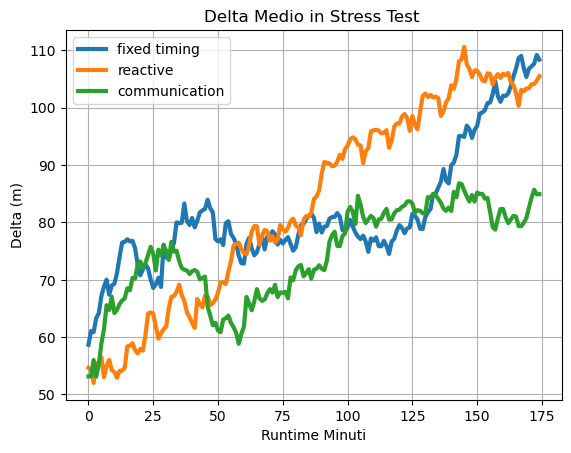

In [69]:
#nome_delta = "delta_medio.png"
#path_delta = os.path.join(plot_folder, nome_delta)
stupid_stress = dfs_stress["stress_batch_stupid_1"]
intelligent_stress = dfs_stress["stress_batch_intelligent_1"]
godly_stress = dfs_stress["stress_batch_godly_1"]

#plot delta stress
plt.plot(stupid_stress['delta_medio'].values,linestyle='-',linewidth=3, label='fixed timing')
plt.plot(intelligent_stress['delta_medio'].values, linestyle='-',linewidth=3, label='reactive')
plt.plot(godly_stress['delta_medio'].values,linestyle='-',linewidth=3, label='communication')

plt.title('Delta Medio in Stress Test ')
plt.ylabel('Delta (m)')
plt.xlabel('Runtime Minuti')
plt.legend()
plt.grid(True)

#salva
#plt.savefig(path_delta, dpi=300, bbox_inches='tight')
plt.show()

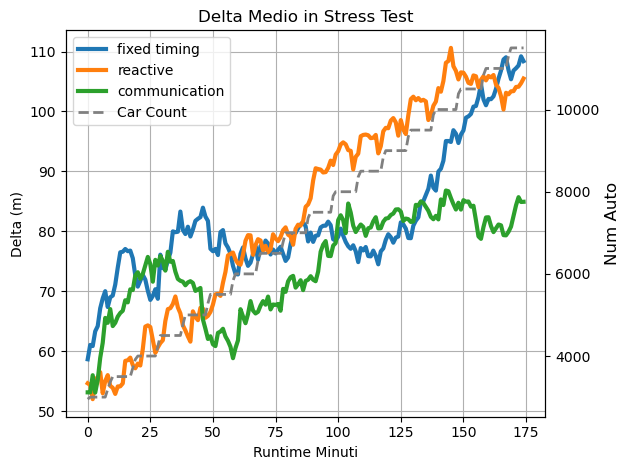

In [77]:
# Asse principale (delta_medio)
nome_delta_stress = "delta_stress.png"
path_delta_stress = os.path.join(plot_folder, nome_delta_stress)
fig, ax1 = plt.subplots()

ax1.plot(stupid_stress['delta_medio'].values, linestyle='-', linewidth=3, label='fixed timing')
ax1.plot(intelligent_stress['delta_medio'].values, linestyle='-', linewidth=3, label='reactive')
ax1.plot(godly_stress['delta_medio'].values, linestyle='-', linewidth=3, label='communication')

ax1.set_ylabel('Delta (m)')
ax1.set_xlabel('Runtime Minuti')
ax1.set_title('Delta Medio in Stress Test')
ax1.grid(True)

# Legenda per delta_medio
#ax1.legend(loc='upper left')

# Secondo asse Y per car count
ax2 = ax1.twinx()

# Assumiamo che car count sia in una colonna chiamata 'car_count'
ax2.plot(stupid_stress['length(car)'].values, linestyle='--', linewidth=2, color='gray', label='Car Count')
ax2.set_ylabel('Num Auto', fontsize=12)

# Legenda combinata (solo se vuoi unificare)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(path_delta_stress, dpi=300, bbox_inches='tight')
plt.show()

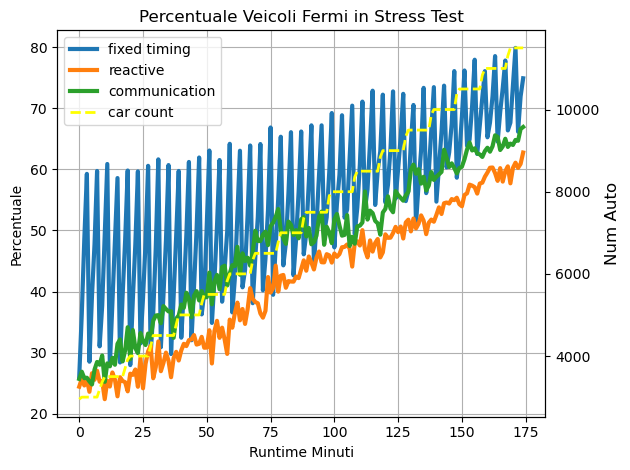

In [81]:
# Percentuale Veicoli fermi
nome_fermi_stress = "fermi_stress.png"
path_fermi_stress = os.path.join(plot_folder, nome_fermi_stress)
fig, ax1 = plt.subplots()

ax1.plot(stupid_stress['auto_ferme'].values, linestyle='-', linewidth=3, label='fixed timing')
ax1.plot(intelligent_stress['auto_ferme'].values, linestyle='-', linewidth=3, label='reactive')
ax1.plot(godly_stress['auto_ferme'].values, linestyle='-', linewidth=3, label='communication')

ax1.set_ylabel('Percentuale')
ax1.set_xlabel('Runtime Minuti')
ax1.set_title('Percentuale Veicoli Fermi in Stress Test')
ax1.grid(True)

# Legenda per delta_medio
#ax1.legend(loc='upper left')

# Secondo asse Y per car count
ax2 = ax1.twinx()

# Assumiamo che car count sia in una colonna chiamata 'car_count'
ax2.plot(stupid_stress['length(car)'].values, linestyle='--', linewidth=2, color='yellow', label='car count')
ax2.set_ylabel('Num Auto', fontsize=12)

# Legenda combinata (solo se vuoi unificare)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(path_fermi_stress, dpi=300, bbox_inches='tight')
plt.show()

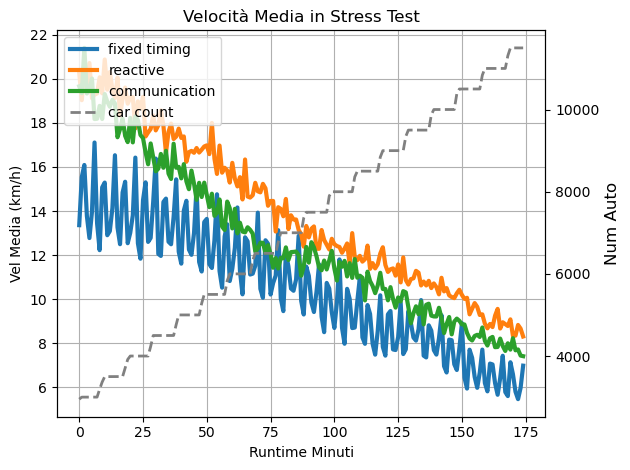

In [82]:
# Asse principale (delta_medio)
nome_vel_stress = "velocity_stress.png"
path_vel_stress = os.path.join(plot_folder, nome_vel_stress)
fig, ax1 = plt.subplots()

ax1.plot(stupid_stress['vel_media'].values, linestyle='-', linewidth=3, label='fixed timing')
ax1.plot(intelligent_stress['vel_media'].values, linestyle='-', linewidth=3, label='reactive')
ax1.plot(godly_stress['vel_media'].values, linestyle='-', linewidth=3, label='communication')

ax1.set_ylabel('Vel Media (km/h)')
ax1.set_xlabel('Runtime Minuti')
ax1.set_title('Velocità Media in Stress Test')
ax1.grid(True)

# Legenda per delta_medio
#ax1.legend(loc='upper left')

# Secondo asse Y per car count
ax2 = ax1.twinx()

# Assumiamo che car count sia in una colonna chiamata 'car_count'
ax2.plot(stupid_stress['length(car)'].values, linestyle='--', linewidth=2, color='gray', label='car count')
ax2.set_ylabel('Num Auto', fontsize=12)

# Legenda combinata (solo se vuoi unificare)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(path_vel_stress, dpi=300, bbox_inches='tight')
plt.show()

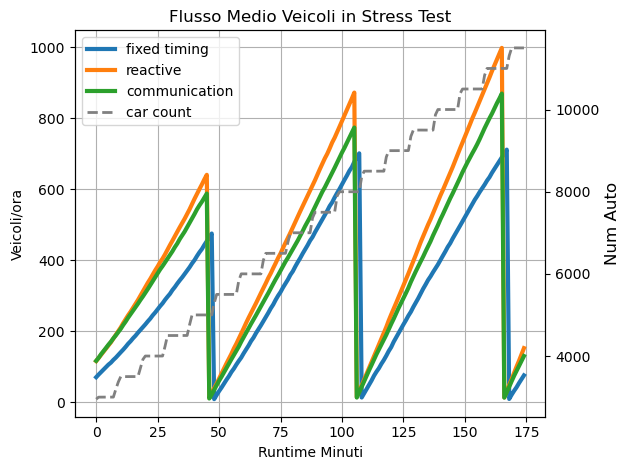

In [85]:
# Percentuale Veicoli fermi
nome_flusso_stress = "flusso_stress.png"
path_flusso_stress = os.path.join(plot_folder, nome_flusso_stress)
fig, ax1 = plt.subplots()

ax1.plot(stupid_stress['flusso_medio'].values, linestyle='-', linewidth=3, label='fixed timing')
ax1.plot(intelligent_stress['flusso_medio'].values, linestyle='-', linewidth=3, label='reactive')
ax1.plot(godly_stress['flusso_medio'].values, linestyle='-', linewidth=3, label='communication')

ax1.set_ylabel('Veicoli/ora')
ax1.set_xlabel('Runtime Minuti')
ax1.set_title('Flusso Medio Veicoli in Stress Test')
ax1.grid(True)

# Legenda per delta_medio
#ax1.legend(loc='upper left')

# Secondo asse Y per car count
ax2 = ax1.twinx()

# Assumiamo che car count sia in una colonna chiamata 'car_count'
ax2.plot(stupid_stress['length(car)'].values, linestyle='--', linewidth=2, color='gray', label='car count')
ax2.set_ylabel('Num Auto', fontsize=12)

# Legenda combinata (solo se vuoi unificare)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(path_flusso_stress, dpi=300, bbox_inches='tight')
plt.show()